In [47]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [48]:
path = Path('data')

In [ ]:
list_of_years = list(range(2011,2024))

In [50]:
list_of_years

[2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

In [51]:
# with open(path/f'cars_database/2013_en.csv', "rb") as f:
#     lines = f.readlines()
#     for i,l in enumerate(lines):
#         print(l)
#         l.decode('utf-8')

In [52]:
frames = []
num_fields = ['MYR', 'OL', 'OW', 'OH ', 'WB', 'CW ', 'A', 'B', 'C','D', 'E', 'F', 'G', 'TWF', 'TWR ', 'YEAR']
for i in list_of_years:
    try:
        with open(path/f'cars_database/{i}_en.csv', 'r') as f:
            df = pd.read_csv(f)
            df['YEAR']  = i
            for field in num_fields:
                df[field] = df[field].astype(float)
        df.columns = ['MAKE', 'MODEL', 'MYR', 'OL', 'OW', 'OH', 'WB', 'CW', 'A', 'B', 'C','D', 'E', 'FH', 'RH', 'TWF', 'TWR', 'WDIST', 'YEAR']
        frames.append(df)
    except:
        print(i, 'has encoding error')

In [53]:
df = pd.concat(frames)

In [54]:
df.head()

,MAKE,MODEL,MYR,OL,OW,OH,WB,CW,A,B,C,D,E,FH,RH,TWF,TWR,WDIST,YEAR
0,ACURA,CSX 4DR SEDAN FWD /TECH PACKAGE,6.0,454.0,175.0,144.0,270.0,1300.0,94.0,45.0,36.0,76.0,110.0,92.0,93.0,150.0,151.0,61/39,2011.0
1,ACURA,MDX 4DR SUV AWD /TECH/ELITE,10.0,485.0,199.0,173.0,275.0,2064.0,117.0,183.0,42.0,85.0,126.0,100.0,110.0,172.0,172.0,56/44,2011.0
2,ACURA,RDX 4DR SUV AWD /TECH PACKAGE,10.0,462.0,187.0,166.0,265.0,1790.0,125.0,152.0,38.0,84.0,124.0,98.0,99.0,158.0,159.0,57/43,2011.0
3,ACURA,RL 4DR SEDAN AWD /ELITE,9.0,497.0,185.0,146.0,280.0,1864.0,125.0,73.0,37.0,80.0,116.0,104.0,111.0,157.0,157.0,58/42,2011.0
4,ACURA,TL 4 DR SEDAN FWD/TECHNOLOGY,9.0,497.0,188.0,145.0,278.0,1682.0,134.0,62.0,34.0,81.0,117.0,105.0,115.0,160.0,161.0,61/39,2011.0


In [55]:
len(df)

11707

In [56]:
df.keys()

Index(['MAKE', 'MODEL', 'MYR', 'OL', 'OW', 'OH', 'WB', 'CW', 'A', 'B', 'C',
       'D', 'E', 'FH', 'RH', 'TWF', 'TWR', 'WDIST', 'YEAR'],
      dtype='object')

#### Descriptive analysis

In [57]:
def get_stats(stat,values):
    if stat == 'max':
        re = np.round(np.nanmax(values),2)
    elif stat == 'min':
        re = np.round(np.nanmin(values),2)
    elif stat == 'std':
        re = np.round(np.nanstd(values),2)
    elif stat == 'mean':
        re = np.round(np.nanmean(values),2)
    return stat, re

In [58]:
for i in ['OH', 'OW', 'WB','RH','FH']:
    print("Dimension",i)
    for k in ['mean', 'min', 'max','std']:
        print(get_stats(k,df[i].values))

Dimension OH
('mean', 168.34)
('min', 110.0)
('max', 305.0)
('std', 32.64)
Dimension OW
('mean', 191.67)
('min', 156.0)
('max', 293.0)
('std', 12.29)
Dimension WB
('mean', 305.63)
('min', 187.0)
('max', 447.0)
('std', 49.3)
Dimension RH
('mean', 107.25)
('min', 39.0)
('max', 202.0)
('std', 18.93)
Dimension FH
('mean', 93.18)
('min', 42.0)
('max', 110.0)
('std', 8.06)


In [59]:
df['TW'] = np.round((df.TWF+df.TWR)/2,1)

In [60]:
np.round(np.mean(df.OW - df.TW),3)

28.289

In [61]:
df.OW.describe()

count    11687.000000
mean       191.674510
std         12.288539
min        156.000000
25%        184.000000
50%        190.000000
75%        201.500000
max        293.000000
Name: OW, dtype: float64

In [62]:
df.OH.describe()

count    11510.000000
mean       168.341268
std         32.642373
min        110.000000
25%        145.000000
50%        163.000000
75%        188.000000
max        305.000000
Name: OH, dtype: float64

In [63]:
df.OL.describe()

count    11703.000000
mean       506.029394
std         68.619590
min        270.000000
25%        462.000000
50%        489.000000
75%        554.000000
max        737.000000
Name: OL, dtype: float64

In [64]:
out_df = df[['OH', 'OW', 'WB','RH','FH','TW']].corr(method='pearson')

In [65]:
out_df.to_latex(index=True,
                      formatters={"name": str.upper},
                      float_format="{:.2f}".format,
                      multirow=True,
                      multicolumn=True,
                      multicolumn_format='c',
                      position='h',
                     bold_rows=True
        )

'\\begin{table}[h]\n\\begin{tabular}{lrrrrrr}\n\\toprule\n & OH & OW & WB & RH & FH & TW \\\\\n\\midrule\n\\textbf{OH} & 1.00 & 0.59 & 0.76 & 0.61 & 0.43 & 0.65 \\\\\n\\textbf{OW} & 0.59 & 1.00 & 0.74 & 0.60 & 0.56 & 0.90 \\\\\n\\textbf{WB} & 0.76 & 0.74 & 1.00 & 0.70 & 0.49 & 0.78 \\\\\n\\textbf{RH} & 0.61 & 0.60 & 0.70 & 1.00 & 0.54 & 0.64 \\\\\n\\textbf{FH} & 0.43 & 0.56 & 0.49 & 0.54 & 1.00 & 0.60 \\\\\n\\textbf{TW} & 0.65 & 0.90 & 0.78 & 0.64 & 0.60 & 1.00 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [66]:
df.OW.describe()

count    11687.000000
mean       191.674510
std         12.288539
min        156.000000
25%        184.000000
50%        190.000000
75%        201.500000
max        293.000000
Name: OW, dtype: float64

In [67]:
np.nanpercentile(df.OW.values, 90)

203.0

In [68]:
df.FH.describe()

count    11207.000000
mean        93.179352
std          8.058247
min         42.000000
25%         88.000000
50%         94.000000
75%        100.000000
max        110.000000
Name: FH, dtype: float64

In [69]:
np.nanpercentile(df.FH.values, 90)

102.0

In [70]:
df.WB.describe()

count    11703.000000
mean       305.631804
std         49.306349
min        187.000000
25%        270.000000
50%        288.000000
75%        330.000000
max        447.000000
Name: WB, dtype: float64

In [71]:
np.nanpercentile(df.WB.values, 90)

385.0

In [72]:
df.RH.describe()

count    11202.000000
mean       107.254687
std         18.934954
min         39.000000
25%         98.000000
50%        109.000000
75%        119.000000
max        202.000000
Name: RH, dtype: float64

In [73]:
np.nanpercentile(df.RH.values, 90)

124.0

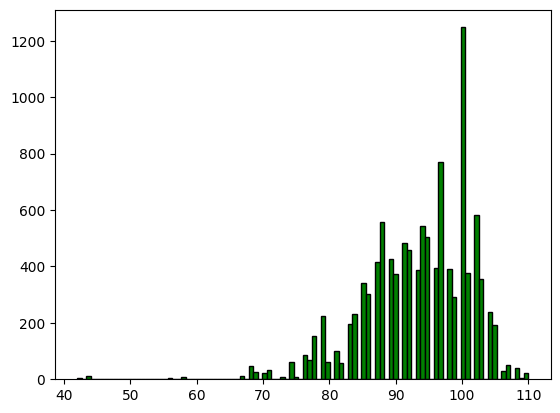

In [74]:
plt.hist(df.FH, bins=100, color='green', edgecolor='black')
plt.show() 

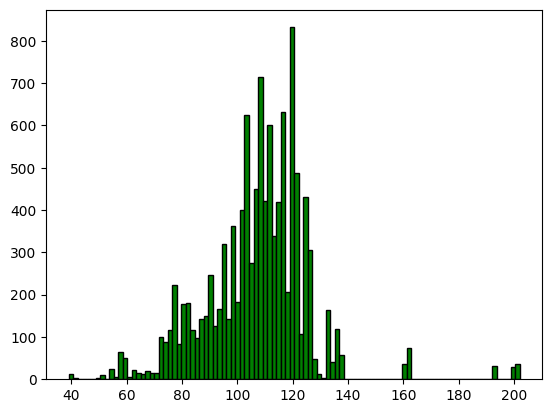

In [75]:
plt.hist(df.RH, bins=100, color='green', edgecolor='black')
plt.show() 

In [76]:
# mu_a = np.mean(sdf[a_part].values,0)
# mu_b = np.mean(sdf[b_part].values,0)
# cov_all = np.cov(sdf.values.T)
# cov_aa = cov_all[:len(a_part),:len(a_part)]
# cov_bb = cov_all[len(a_part):,len(a_part):]
# cov_bb_inv = np.linalg.inv(cov_bb)
# cov_ab = cov_all[:len(a_part),len(a_part):]
# #For single example
# mu_a+cov_ab@cov_bb_inv@(sdf[b_part].values[0]-mu_b)
# pred = mu_a+((sdf[b_part].values-mu_b)@cov_bb_inv.T)@cov_ab.T
# dim = 1
# print(a_part[dim])
# np.sum(abs(pred[:,dim]-sdf[a_part].values[:,dim]))/pred.shape[0]
# np.sum(abs(pred[:,1]-sdf[a_part].values[:,1]))/pred.shape[0]

In [77]:
def estimate_ab(a_part, b_part,df):
    ab = a_part + b_part
    sdf = df[df[ab].notna().all(axis=1)][ab]
    mu_a = np.mean(sdf[a_part].values,0)
    mu_b = np.mean(sdf[b_part].values,0)
    cov_all = np.cov(sdf.values.T)
    cov_aa = cov_all[:len(a_part),:len(a_part)]
    cov_bb = cov_all[len(a_part):,len(a_part):]
    cov_bb_inv = np.linalg.inv(cov_bb)
    cov_ab = cov_all[:len(a_part),len(a_part):]
    pred = mu_a+((sdf[b_part].values-mu_b)@cov_bb_inv.T)@cov_ab.T
    for i in range(len(a_part)):
        print(a_part[i])
        error = np.sum(abs(pred[:,i]-sdf[a_part].values[:,i]))/pred.shape[0]
        print('Error',round(error,3))
    return mu_a, cov_ab, cov_bb_inv, mu_b

In [78]:
def predict_a_from_b(b_vector):
    mu_a, cov_ab, cov_bb_inv, mu_b = estimate_ab(a_part, b_part,df)
    print(mu_a.shape, cov_ab.shape, cov_bb_inv.shape, (b_vector-mu_b).shape)
    re = mu_a+cov_ab@cov_bb_inv@(b_vector-mu_b)
    print(re)

In [79]:
b_part = ['OH', 'OW', 'WB']
a_part = ['RH', 'FH']
ab = a_part + b_part
print(ab)
sdf = df[df[ab].notna().all(axis=1)][ab]

['RH', 'FH', 'OH', 'OW', 'WB']


In [80]:
b_vector = sdf[b_part].values[9]
print(sdf[a_part].values[0])

[93. 92.]


In [81]:
predict_a_from_b(b_vector)

RH
Error 10.213
FH
Error 5.058
(2,) (2, 3) (3, 3) (3,)
[91.45883575 86.60982605]


In [82]:
scenarios = [[['RH', 'FH', 'OH'],['OW', 'WB']],
             [['RH', 'FH', 'OH', 'WB'],['OW']],
             [['OW'],['WB']],
             [['OW'],['TW']],
            ]

In [83]:
car_model_param = dict()
for i in scenarios:
    a_part = i[0]
    b_part = i[1]
    s_name = f"{'_'.join(a_part)}__{'_'.join(b_part)}"
    print(s_name)
    mu_a, cov_ab, cov_bb_inv, mu_b = estimate_ab(a_part, b_part,df)
    car_model_param[s_name] = [mu_a, cov_ab, cov_bb_inv, mu_b]
    print("---")

RH_FH_OH__OW_WB
RH
Error 10.068
FH
Error 5.127
OH
Error 15.959
---
RH_FH_OH_WB__OW
RH
Error 10.538
FH
Error 5.176
OH
Error 17.268
WB
Error 23.013
---
OW__WB
OW
Error 5.859
---
OW__TW
OW
Error 2.692
---


In [84]:
car_model_param

{'RH_FH_OH__OW_WB': [array([107.06212534,  93.05803815, 169.73451408]),
  array([[ 139.09187563,  655.44286966],
         [  54.37262166,  189.41866009],
         [ 239.79374143, 1196.21838052]]),
  array([[ 0.0160372 , -0.00295692],
         [-0.00295692,  0.00096778]]),
  array([191.17184378, 304.92170754])],
 'RH_FH_OH_WB__OW': [array([107.06212534,  93.05803815, 169.73451408, 304.92170754]),
  array([[139.09187563],
         [ 54.37262166],
         [239.79374143],
         [436.30894081]]),
  array([[0.00700275]]),
  array([191.17184378])],
 'OW__WB': [array([191.67451014]),
  array([[445.84241587]]),
  array([[0.0004112]]),
  array([305.66757936])],
 'OW__TW': [array([191.1125583]),
  array([[83.57562363]]),
  array([[0.01499616]]),
  array([162.82350612])]}

In [85]:
import pickle

In [86]:
# with open('car_model_param.pkl', 'wb') as file:
#     pickle.dump(car_model_param, file)

In [87]:
import scipy.io

In [88]:
# scipy.io.savemat('car_model_param.mat', {'RH-FH|OH-OW-WB': car_model_param['RH-FH|OH-OW-WB'],
#                                         'RH-FH|OW-WB':car_model_param['RH-FH|OW-WB'], 
# #                                         'RH-FH-WB|OH-OW':car_model_param['RH-FH-WB|OH-OW'],
# #                                         'RH-FH-WB|OW':car_model_param['RH-FH-WB|OW'],
#                                         })

In [89]:
flat_car_model = dict()
for k,v in car_model_param.items():
    print(k,v)
    flats = []
    for i in v:
        print(i.shape)
        flats.append(i.flatten())
    flat_car_model[k] = np.concatenate(flats, axis=0)

RH_FH_OH__OW_WB [array([107.06212534,  93.05803815, 169.73451408]), array([[ 139.09187563,  655.44286966],
       [  54.37262166,  189.41866009],
       [ 239.79374143, 1196.21838052]]), array([[ 0.0160372 , -0.00295692],
       [-0.00295692,  0.00096778]]), array([191.17184378, 304.92170754])]
(3,)
(3, 2)
(2, 2)
(2,)
RH_FH_OH_WB__OW [array([107.06212534,  93.05803815, 169.73451408, 304.92170754]), array([[139.09187563],
       [ 54.37262166],
       [239.79374143],
       [436.30894081]]), array([[0.00700275]]), array([191.17184378])]
(4,)
(4, 1)
(1, 1)
(1,)
OW__WB [array([191.67451014]), array([[445.84241587]]), array([[0.0004112]]), array([305.66757936])]
(1,)
(1, 1)
(1, 1)
(1,)
OW__TW [array([191.1125583]), array([[83.57562363]]), array([[0.01499616]]), array([162.82350612])]
(1,)
(1, 1)
(1, 1)
(1,)


In [45]:
flat_car_model

{'RH_FH_OH__OW_WB': array([ 1.07062125e+02,  9.30580381e+01,  1.69734514e+02,  1.39091876e+02,
         6.55442870e+02,  5.43726217e+01,  1.89418660e+02,  2.39793741e+02,
         1.19621838e+03,  1.60372004e-02, -2.95691675e-03, -2.95691675e-03,
         9.67779495e-04,  1.91171844e+02,  3.04921708e+02]),
 'RH_FH_OH_WB__OW': array([1.07062125e+02, 9.30580381e+01, 1.69734514e+02, 3.04921708e+02,
        1.39091876e+02, 5.43726217e+01, 2.39793741e+02, 4.36308941e+02,
        7.00274913e-03, 1.91171844e+02]),
 'OW__WB': array([1.91674510e+02, 4.45842416e+02, 4.11201406e-04, 3.05667579e+02]),
 'OW__TW': array([1.91112558e+02, 8.35756236e+01, 1.49961568e-02, 1.62823506e+02])}

In [46]:
scipy.io.savemat('car_model_param_202405.mat', flat_car_model)

### Get the car dimensions for the tracks

In [90]:
model = 'Civic'
make= 'Honda'

In [91]:
filtered_df = df[df.MODEL.str.contains(model, case=False, na=False) & df.MAKE.str.contains(make, case=False, na=False)]

In [92]:
#Run for the pipeline

In [93]:
critical_dims = ['OL', 'OW', 'OH', 'WB', 'TW']
vis_dims = ['MAKE','MODEL','YEAR','OL', 'OW', 'OH', 'WB','TW']

In [94]:
same_dims = True
for d in critical_dims:
    deviation = np.nanstd(filtered_df[d].values)/np.nanmean(filtered_df[d].values)
    if deviation >= 0.05:
        same_dims = False
        break

In [95]:
if same_dims:
    print(filtered_df[vis_dims].head())
    print(np.round(np.mean(filtered_df[critical_dims].values,0),3))

      MAKE                                MODEL    YEAR     OL     OW     OH  \
396  HONDA          CIVIC 2DR COUPE FWD DX-G/SE  2011.0  444.0  175.0  136.0   
397  HONDA             CIVIC 2DR COUPE FWD EX-L  2011.0  444.0  175.0  136.0   
398  HONDA               CIVIC 2DR COUPE FWD Si  2011.0  444.0  175.0  136.0   
399  HONDA  CIVIC 4DR SEDAN FWD DX/DX-G/SE/EX-L  2011.0  449.0  175.0  144.0   
400  HONDA                   CIVIC 4DR SEDAN Si  2011.0  449.0  175.0  144.0   

        WB     TW  
396  265.0  150.5  
397  265.0  150.5  
398  265.0  150.5  
399  270.0  149.5  
400  270.0  149.5  
[454.157 182.657 141.657 268.586 153.6  ]


In [96]:
# all_vehicles = ["Mitsubishi Outlander",
# "BMW X4",
# "Lincoln MKZ",
# "Hyundai Tucson",
# "Ford Mondeo",
# "Volkswagen Tiguan",
# "Audi A6",
# "Toyota Corolla",
# "Kia Cadenza",
# "Hyundai Sonata",
# "Audi A3",
# "Audi A6",
# "Lincoln MKZ",
# "Mercedes-Benz E Class",
# "Honda Accord",
# "Toyota Corolla",
# "Kia Cadenza",
# "Chevrolet Equinox",
# "Honda XR-V"]

In [97]:
# all_tracks = ["s0_track_17",
# "s0_track_18",
# "s0_track_25",
# "s0_track_37",
# "s0_track_42",
# "s4_track_3",
# "s4_track_17",
# "s4_track_25",
# "s4_track_35",
# "s12_track_1",
# "s12_track_6",
# "s12_track_10",
# "s12_track_12",
# "s12_track_13",
# "s12_track_20",
# "s12_track_33",
# "s12_track_35",
# "s12_track_37",
# "s12_track_44"]

In [98]:
# assert len(all_vehicles) == len(all_tracks)

In [100]:
def get_tracks_dims(all_vehicles,all_tracks):
    tracks_dims = dict()
    for m,i in enumerate(all_vehicles):
        i = i.replace('\n', '')
        splitted = i.split()
        make = splitted[0]
        model = " ".join(splitted[1:])
        model = model.replace('\n', '')
        # print(splitted,model)
        filtered_df = df[df.MODEL.str.contains(model, case=False, na=False) & df.MAKE.str.contains(make, case=False, na=False)]
        if len(filtered_df) > 0:
            same_dims = True
            for d in critical_dims:
                deviation = np.nanstd(filtered_df[d].values)/np.nanmean(filtered_df[d].values)
                if deviation >= 0.05: #If standard deviation is more than 5% from the mean
                    same_dims = False
                    break
            if same_dims:
                avg_dims = np.round(np.mean(filtered_df[critical_dims].values,0),3)
                dims_dict = dict(zip(critical_dims,avg_dims))
                tracks_dims[all_tracks[m]] = {i:dims_dict}
            else:
                print(make,model,"NOT same dims")
        else:
            print(make,model,'NOT found')
    return tracks_dims

In [101]:
## Read from excel to have autmatic 

In [102]:
path = Path('.')

In [103]:
seqs = [9,3805, 4993, 7703, 12351, 15596]

In [104]:
all_seqs_make_model = dict()
for s in seqs:
    with open(path/f"make_model_data/Seq {s}.csv",'r') as f:
        mdf = pd.read_csv(f)
    mdf = mdf[mdf["Google image search result"].notnull()]
    mdf = mdf[mdf["Google image search result"].apply(len) > 2]
    all_vehicles = mdf['Google image search result'].values
    all_tracks = mdf.Track.values
    track_dims = get_tracks_dims(all_vehicles,all_tracks)
    all_seqs_make_model[s] = track_dims
    print(s, 'num valid tracks', len(track_dims), 'as a percentage', round(len(track_dims)/len(all_tracks)*100,2))
    print("=====")

Ford Mondeo NOT found
Mercedes-Benz E-Class NOT found
Honda XR-V NOT found
9 num valid tracks 16 as a percentage 84.21
=====
Mercedes-Benz E-Class NOT found
Volkswagen Jetta (A6) NOT found
Nissan Sylphy NOT found


/tmp/ipykernel_13820/3569627708.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_df = df[df.MODEL.str.contains(model, case=False, na=False) & df.MAKE.str.contains(make, case=False, na=False)]


Hyundai Starex NOT found
3805 num valid tracks 6 as a percentage 60.0
=====
Toyota Crown NOT found
Toyota Alphard NOT found
Volkswagen New Beetle NOT found
Nio ES8 NOT found
Hyundai Ioniq NOT same dims
Mini  NOT same dims
BMW 5-Series NOT found
Buick GL8 NOT found
Buick Excelle NOT found
Trumpchi GM8 NOT found
BYD Qin NOT found
Brilliance V5 NOT found
Hyundai Starex NOT found
Volkswagen Polo NOT found
Mercedes-Benz V-class NOT found
Nissan Teana NOT found
Dongfeng Junfeng NOT found
Aion S NOT found
Land Rover Discovery Sport NOT found
Buick GL8 NOT found
Buick GL8 NOT found
Ford Kuga NOT found
Maruti Esteem NOT found
Nissan Sylphy NOT found
Nissan Sentra SL NOT found
Mercedes-Benz Viano NOT found
Buick GL8 NOT found
Volkswagen Lavida NOT found
Nissan Livina NOT found
Opel Insignia NOT found
BMW 5-Series NOT found
Toyota HiAce NOT found
Wuling Hongtu NOT found
Mercedes-Benz B-Class NOT found
Nissan Teana NOT found
Chery Arrizo 5 NOT found
4993 num valid tracks 50 as a percentage 58.14
=

/tmp/ipykernel_13820/3569627708.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_df = df[df.MODEL.str.contains(model, case=False, na=False) & df.MAKE.str.contains(make, case=False, na=False)]


Toyota HiAce NOT found
Nissan Teana NOT found
Mercedes-Benz CLK NOT found
Mazda6  NOT found
Škoda Superb NOT found
Ford Transit NOT same dims
Honda Elysion NOT found
Lifan 720 NOT found
Hyundai Creta NOT found
Hyundai Starex NOT found
Nissan Sylphy NOT found
7703 num valid tracks 18 as a percentage 46.15
=====
Volkswagen Polo NOT found
Changan BenBen NOT found
Volkswagen Phideon NOT found
BYD Qin NOT found
BMW 5-Series NOT found
Toyota Land Cruiser NOT found
Mercedes-Benz E-Class NOT found
Chevrolet Captiva NOT found
Škoda Superb NOT found
Volkswagen New Santana NOT found
MG MG5 Com Excite NOT found
Keyton EX80 NOT found
Lincoln MKX QAA Stainless Steel Rear Deck Trim RD56660 NOT found
Hyundai Elantra Sport NOT found
Volkswagen Magotan NOT found
Buick GL8 NOT found
Nissan Sunny NOT found
Buick GL8 NOT found
Toyota Belta NOT found
Changan CS55 NOT found
Geely Emgrand L NOT found
Volkswagen Phideon NOT found
Hyundai ix35 NOT found
Nissan Sylphy NOT found
Nissan Versa 1.6 SV NOT found
Volk

/tmp/ipykernel_13820/3569627708.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtered_df = df[df.MODEL.str.contains(model, case=False, na=False) & df.MAKE.str.contains(make, case=False, na=False)]


Mitsubishi Pajero NOT found
Volkswagen Polo NOT found
Volkswagen Santana NOT found
Nissan Teana NOT found
Nissan Teana NOT found
Geely Emgrand NOT found
Nissan Sylphy NOT found
BMW 5-Series NOT found
Honda City NOT found
BYD Qin NOT found
Škoda Fabia NOT found
Haval H2 NOT found
BYD S6 NOT found
Nissan Sylphy NOT found
Nissan Teana NOT found
Land Rover Range Rover NOT found
BYD L3 NOT found
Keyton EX80 NOT found
BJEV EC3 NOT found
15596 num valid tracks 24 as a percentage 47.06
=====


In [105]:
path.resolve()

PosixPath('/home/thaotrongtran/Projects/sym3D_python')

In [106]:
import json

In [108]:
# all_seqs_make_model

In [120]:
with open(path/'all_seqs_make_model_20240319.json', 'w') as f:
    json.dump(all_seqs_make_model, f)

### Highway 7

In [121]:
path = Path(".")

In [130]:
all_seqs_make_model = dict()
s = "seg23_sc4"
with open(path/f"make_model_data/{s}.csv",'r') as f:
    mdf = pd.read_csv(f)
    mdf = mdf[mdf["Google image search result"].notnull()]
    mdf = mdf[mdf["Google image search result"].apply(len) > 2]
    all_vehicles = mdf['Google image search result'].values
    all_tracks = mdf.Track.values
    track_dims = get_tracks_dims(all_vehicles,all_tracks)
    print(track_dims)
    all_seqs_make_model[s] = track_dims
    print(s, 'num valid tracks', len(track_dims), 'as a percentage', round(len(track_dims)/len(all_tracks)*100,2))
    print("=====")

Honda Pilot EX NOT found
Ford F-150 NOT same dims
Ford F-150 NOT same dims
Ford Transit NOT same dims
Honda Pilot Elite NOT found
Jetta Sportwagen NOT found
Mercedes-Benz E-Class NOT found
Mercedes-Benz B-Class NOT found
{'04F1E2F9-0F15-4EFA-AC0D-4F38787578FA': {'Toyota 4Runner': {'OL': 482.0, 'OW': 193.0, 'OH': 183.111, 'WB': 279.0, 'TW': 160.222}}, '36BF7EF2-D193-4ABB-A9FF-916331490C7A': {'Mercedes-Benz C300 4MATIC': {'OL': 469.0, 'OW': 180.692, 'OH': 140.308, 'WB': 283.385, 'TW': 155.154}}, '9C20429D-C414-4866-87D6-40478EF29A46': {'Mercedes-Benz GLC': {'OL': 468.838, 'OW': 188.622, 'OH': 162.108, 'WB': 287.0, 'TW': 162.0}}, '74E40AE3-26D3-4F4F-ADC7-0FDD4F2A6EE8': {'Toyota Corolla': {'OL': 454.4, 'OW': 177.733, 'OH': 146.767, 'WB': 266.067, 'TW': 154.567}}, '22F1C762-1923-4677-A9C2-18C870FF8B88': {'Ford Escape': {'OL': 454.25, 'OW': 185.2, 'OH': 169.0, 'WB': 268.5, 'TW': 156.85}}, '4ABEDF51-4BA5-44B9-A5CF-6E00BFF70799': {'Acura MDX': {'OL': 495.8, 'OW': 197.667, 'OH': 171.133, 'WB': 

In [131]:
with open(path/f'hw7_saved_make_model/{s}_make_model_20240319.json', 'w') as f:
    json.dump(all_seqs_make_model, f)